# Start

In [3]:
import pandas as pd

windows = pd.read_csv("data\\windows_manifest.csv")
scenarios = pd.read_csv("data\\dataset_manifest.csv")

## npz files

In [4]:
import numpy as np

data = np.load("data\\windows\\000003_000.npz", allow_pickle=True)
print(data.files)
print(data["input"].shape)
print(data["target"].shape)

['scenario_id', 'window_id', 'input', 'target']
(3, 1, 64, 64)
(1, 1, 64, 64)


## Visualization

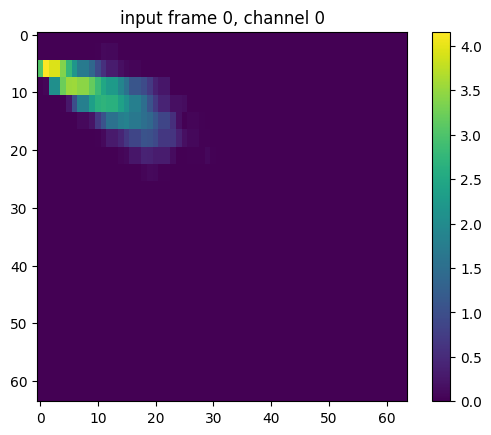

In [5]:
import matplotlib.pyplot as plt

x = data["input"]  # shape e.g. (3, C, 64, 64)
y = data["target"] # shape e.g. (1, C, 64, 64)

plt.imshow(x[0, 0], cmap="viridis")
plt.title("input frame 0, channel 0")
plt.colorbar()
plt.show()

## EDA Overview

In [6]:
import os

print("Windows manifest shape:", windows.shape)
print("Scenario manifest shape:", scenarios.shape)
print("Unique scenarios in windows manifest:", windows["scenario_id"].nunique())
print("Sample paths in windows manifest:\n", windows["sample_path"].head())
print()

scenarios.rename(columns=lambda col: col.strip(), inplace=True)
scenarios["start_time"] = pd.to_datetime(scenarios["start_time"].astype(str).str.strip(), errors="coerce")
print("Scenario columns:", list(scenarios.columns))
print(scenarios[["lat", "lon", "height_m", "run_hours", "emission_rate", "tensor_min", "tensor_max", "tensor_mean", "nonzero_cells"]].describe())
print()
print("Start time range:", scenarios["start_time"].min(), "to", scenarios["start_time"].max())
print()
print(windows["scenario_id"].value_counts().describe())

Windows manifest shape: (40215, 7)
Scenario manifest shape: (10000, 15)
Unique scenarios in windows manifest: 8177
Sample paths in windows manifest:
 0    /workspace/hysplit_dataset_convlstm/windows/00...
1    /workspace/hysplit_dataset_convlstm/windows/00...
2    /workspace/hysplit_dataset_convlstm/windows/00...
3    /workspace/hysplit_dataset_convlstm/windows/00...
4    /workspace/hysplit_dataset_convlstm/windows/00...
Name: sample_path, dtype: object

Scenario columns: ['scenario_id', 'start_time', 'lat', 'lon', 'height_m', 'run_hours', 'emission_rate', 'sample_path', 'time_steps', 'grid_h', 'grid_w', 'tensor_min', 'tensor_max', 'tensor_mean', 'nonzero_cells']
                lat           lon      height_m    run_hours  emission_rate  \
count  10000.000000  10000.000000  10000.000000  10000.00000   10000.000000   
mean      52.198101      5.205621     67.211000      7.20930       2.239100   
std        0.810391      1.135592     54.220895      2.72669       2.292347   
min       50

## Metadata Distributions

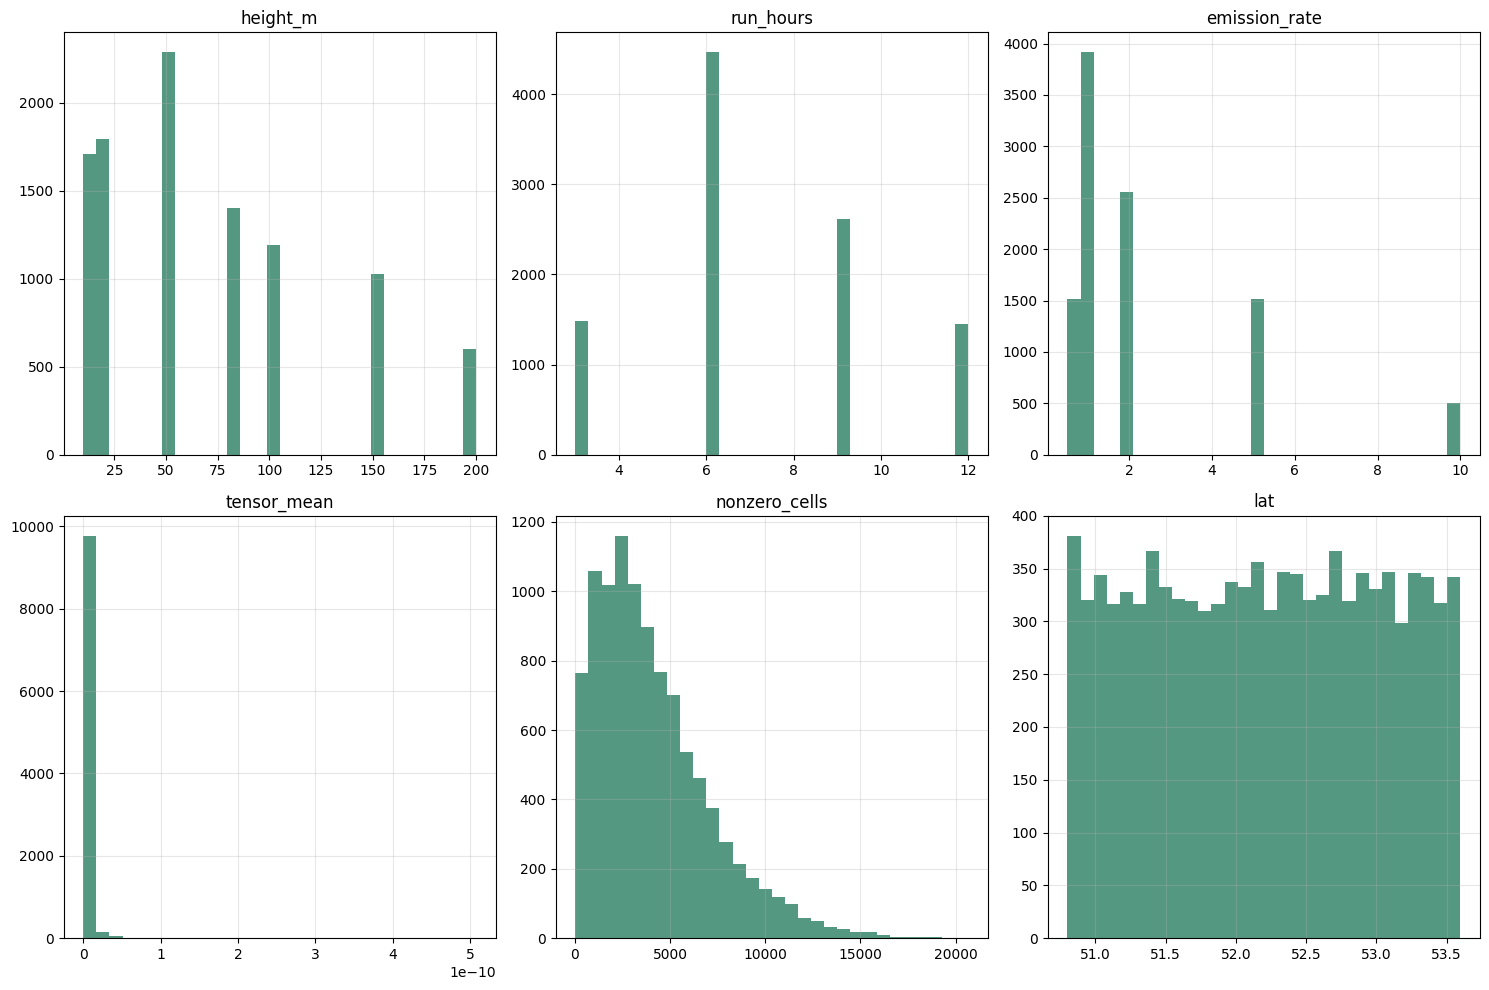

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = ["height_m", "run_hours", "emission_rate", "tensor_mean", "nonzero_cells", "lat"]
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axs.flat, numeric_cols):
    values = scenarios[col].astype(float)
    ax.hist(values.dropna(), bins=30, color="#2a7f62", alpha=0.8)
    ax.set_title(col)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Sample Window Statistics and Visual Checks

Inspecting sample files:
000003_000.npz: input (3, 1, 64, 64), target (1, 1, 64, 64)
  input min/max/mean: 0.0000e+00, 4.1589e+00, 2.4132e-01
  target min/max/mean: 0.0000e+00, 4.0604e+00, 3.2414e-01

000003_001.npz: input (3, 1, 64, 64), target (1, 1, 64, 64)
  input min/max/mean: 0.0000e+00, 4.1431e+00, 3.1631e-01
  target min/max/mean: 0.0000e+00, 3.9703e+00, 3.0014e-01

000003_002.npz: input (3, 1, 64, 64), target (1, 1, 64, 64)
  input min/max/mean: 0.0000e+00, 4.1271e+00, 3.2806e-01
  target min/max/mean: 0.0000e+00, 3.8918e+00, 2.8460e-01



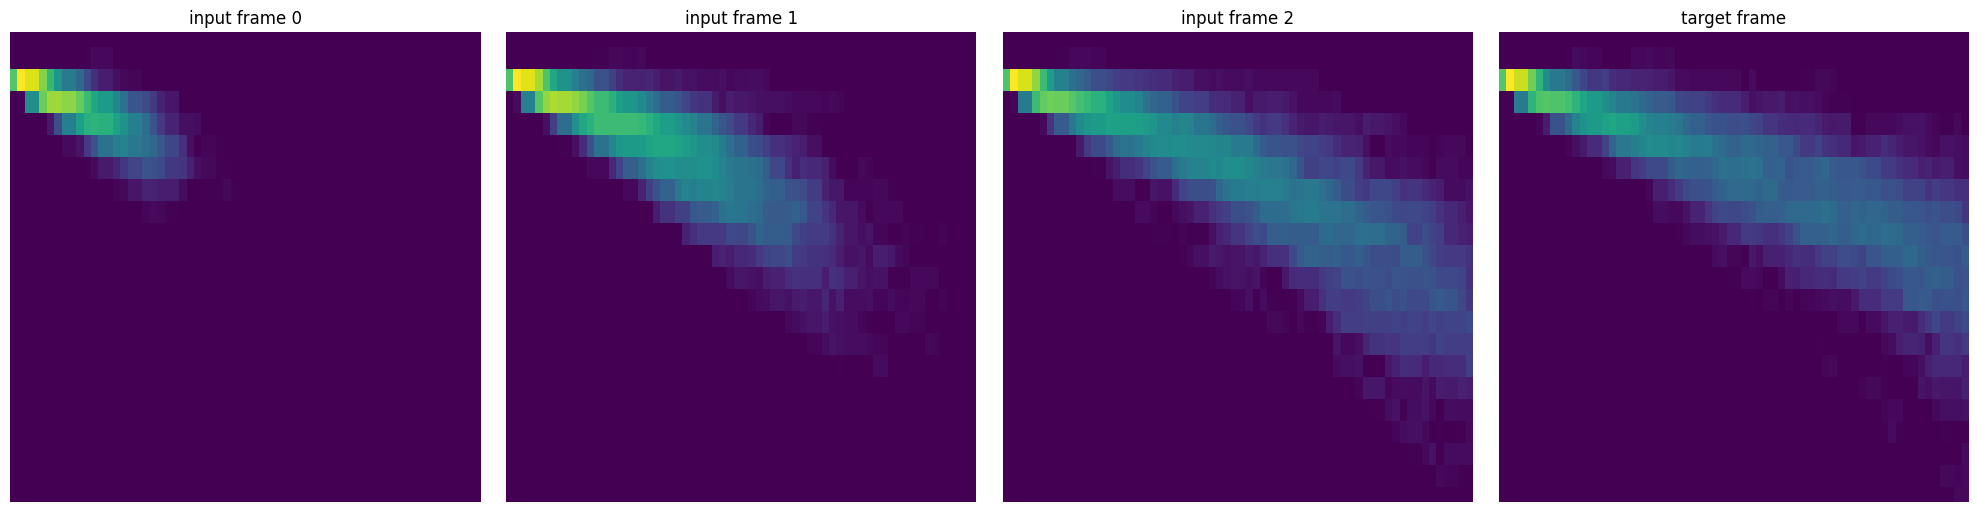

In [ ]:
from pathlib import Path

sample_names = windows["sample_path"].head(3).apply(lambda p: Path(p).name)
print("Inspecting sample files:")
for name in sample_names:
    sample_path = Path("windows") / name
    sample_data = np.load(sample_path, allow_pickle=True)
    inp = sample_data["input"].astype(float)
    tgt = sample_data["target"].astype(float)
    print(f"{name}: input {inp.shape}, target {tgt.shape}")
    print(f"  input min/max/mean: {inp.min():.4e}, {inp.max():.4e}, {inp.mean():.4e}")
    print(f"  target min/max/mean: {tgt.min():.4e}, {tgt.max():.4e}, {tgt.mean():.4e}")
    print()

sample_path = Path("windows") / sample_names.iloc[0]
data = np.load(sample_path, allow_pickle=True)
input_sample = data["input"]
target_sample = data["target"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(3):
    axes[i].imshow(input_sample[i, 0], cmap="viridis")
    axes[i].set_title(f"input frame {i}")
    axes[i].axis("off")

axes[3].imshow(target_sample[0, 0], cmap="viridis")
axes[3].set_title("target frame")
axes[3].axis("off")

plt.tight_layout()
plt.show()